
# Model 2 — Banana Leaf Segmentation (leaf region + damage region)

**Task:** 2-channel binary semantic segmentation — `leaf` (full leaf silhouette) and `affected`
(any disease-damaged tissue, disease-type-agnostic) — per `Backend/docs/adr/0012-model2-pipeline-and-contract.md`.

## Relationship to the reference repo

`xaugatp/PRT691_AIPratices/02_banana_leaf_segmentation.ipynb` establishes the architecture this
notebook reuses: `smp.Unet(resnet34, imagenet)`, 512×512, 2 sigmoid output channels, weighted
BCE+Dice combo loss with pixel-ratio-derived `pos_weight`. That notebook trained on 50 images (2
healthy). This notebook retrains the same architecture on the new, much larger export — **161
images, 85 of them healthy** — and fixes one methodological issue flagged in ADR 0012:

> *"The 0.85 threshold was tuned on the test split (optimistic)."*

Section 8.2 below tunes the binarization threshold on the **validation** split and reports final
numbers on a held-out **test** split the threshold never saw.

## Data audit findings

| Finding | Detail |
|---|---|
| Source | `Data/Leaf Segmentation.v1i.yolov8.zip` — 161 images (115/30/16 train/valid/test), YOLO-polygon labels |
| Classes | `Leaf_boundary`, `black_sigatoka_disease`, `cordana`, `healthy_leaf`, `yellow_sigatoka` |
| Leakage check | Each image's filename stem is unique across all three Roboflow splits — **no cross-split duplication found** (unlike the tree-detection set). Roboflow's split is used as a starting point but we still re-run our own grouped split for consistency and to control the exact ratios. |
| Per-image structure | Every image has a `Leaf_boundary` polygon plus **exactly one** of `{healthy_leaf, black_sigatoka_disease, cordana, yellow_sigatoka}` (verified: zero images mix two disease categories) — confirms "affected" is correctly modelled as a subset of "leaf", same assumption the reference repo made. |
| `cordana` | Only 1 image in the full 161-image set. Too sparse to validate on; merged into the generic `affected` channel here (this notebook doesn't need to tell disease types apart — Model 3 does), so it still contributes signal without needing its own split allocation. |
| `Data/Old/banana-leaf-segmentation.*` | An earlier 50-image, 4-raw-category version (matches the reference repo exactly: `leaf-boundary`, `affected-area`, `banana-leaf-lesions`, `unhealthy_leaf`). Superseded; not used for training. |


## 0. Environment Setup

In [1]:

import sys
sys.path.insert(0, ".")
from common import (
    set_seed, pick_device, extract_zip_once, strip_roboflow_suffix,
    group_shuffle_split_3way, read_yolo_label_file, polygon_row_to_mask,
    dice_score, pixel_confusion, compute_pos_weight, DiceLoss, ComboLoss,
    detect_hardware, recommend_batch_size, save_fig,
)

import os, time, shutil, itertools
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

SEED = 42
set_seed(SEED)
DEVICE = pick_device()
print("Training device:", DEVICE)
sns.set_theme(style="whitegrid")


Torch version: 2.14.1+cpu
CUDA available: False
Training device: cpu



## 1. Configuration

### 1.1 Hardware check — batch size is derived from it, not hard-coded

A U-Net at 512×512 is memory-heavier per image than the classifier in Notebook 01. We scale a
4-image baseline (sized for an 8GB-RAM CPU machine) by measured available RAM (or VRAM, on a CUDA
box), clamped to [4, 16] — large enough to benefit from more RAM, small enough that
`GRAD_ACCUM_STEPS` still meaningfully raises the *effective* batch size without re-tuning it.


In [2]:

SMOKE_TEST = os.environ.get("SMOKE_TEST", "0") == "1"

HW = detect_hardware()
print("Hardware detected:", HW)
if HW["cuda_available"]:
    print(f"GPU: {HW['gpu_name']} ({HW['vram_total_gb']} GB VRAM) -> training will use CUDA.")
else:
    print(f"No CUDA GPU detected -> training on CPU ({HW['cpu_logical_cores']} logical cores).")

RAW_ZIP = Path("../Data/Leaf Segmentation.v1i.yolov8.zip")
RAW_DIR = extract_zip_once(RAW_ZIP, Path("data_cache/leaf_seg_raw"))

WORK_DIR = Path("stage2_work")
CACHE_DIR = WORK_DIR / "mask_cache"
CHECKPOINT_DIR = WORK_DIR / "checkpoints"
OUTPUT_DIR = Path("outputs/leaf_segmentation")
FIGURES_DIR = Path("figures/leaf_segmentation")
for d in [WORK_DIR, CACHE_DIR, CHECKPOINT_DIR, OUTPUT_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 512          # fixed by ADR 0012 production contract — the deployed net expects 512x512
BATCH_SIZE = min(16, recommend_batch_size(HW, base_batch=4, base_ram_gb=8.0)) if not SMOKE_TEST else 4
GRAD_ACCUM_STEPS = 2
ENCODER_NAME = "resnet34"
EPOCHS = 80 if not SMOKE_TEST else 2
PATIENCE = 15 if not SMOKE_TEST else 2   # early stopping: epochs with no val Dice improvement
LR = 1e-4
WEIGHT_DECAY = 1e-4
WARMUP_EPOCHS = 5

# class_id (data.yaml) -> output channel. healthy_leaf is NOT unioned into "affected" —
# it is the complement of affected within the leaf and needs no explicit channel.
CLASS_ID_TO_NAME = {0: "Leaf_boundary", 1: "black_sigatoka_disease", 2: "cordana",
                     3: "healthy_leaf", 4: "yellow_sigatoka"}
CATEGORY_MAP = {
    "Leaf_boundary": "leaf",
    "black_sigatoka_disease": "affected",
    "cordana": "affected",
    "yellow_sigatoka": "affected",
    # "healthy_leaf" intentionally excluded — it is background within the leaf, not a channel.
}
CHANNEL_NAMES = ["leaf", "affected"]

print(f"SMOKE_TEST={SMOKE_TEST}  BATCH_SIZE={BATCH_SIZE} (hardware-adapted)  EPOCHS={EPOCHS}  PATIENCE={PATIENCE}")
assert RAW_DIR.exists()


Hardware detected: {'cpu_logical_cores': 16, 'ram_total_gb': 33.8, 'ram_available_gb': 15.3, 'cuda_available': False, 'gpu_name': None, 'vram_total_gb': None}
No CUDA GPU detected -> training on CPU (16 logical cores).


SMOKE_TEST=False  BATCH_SIZE=8 (hardware-adapted)  EPOCHS=80  PATIENCE=15


## 2. Data Exploration (EDA)

### 2.1 Category counts & co-occurrence

In [3]:

def collect_split_rows(split):
    img_dir = RAW_DIR / split / "images"
    lbl_dir = RAW_DIR / split / "labels"
    out = []
    for f in sorted(os.listdir(img_dir)):
        stem = Path(f).stem
        rows = read_yolo_label_file(lbl_dir / f"{stem}.txt")
        out.append({"split": split, "file": f, "stem": stem, "rows": rows})
    return out

all_rows = []
for s in ["train", "valid", "test"]:
    all_rows += collect_split_rows(s)
meta_df = pd.DataFrame(all_rows)
print(f"Total images: {len(meta_df)}")

ann_counter = Counter()
combo_counter = Counter()
for _, r in meta_df.iterrows():
    cls_names_present = sorted(set(CLASS_ID_TO_NAME[int(row[0])] for row in r["rows"]))
    for c in cls_names_present:
        ann_counter[c] += 1
    disease_only = sorted(c for c in cls_names_present if c != "Leaf_boundary")
    combo_counter[tuple(disease_only)] += 1

print("\nImages containing each category:")
for k, v in ann_counter.items():
    print(f"  {k}: {v}")

print("\nDisease-category combinations per image (excluding Leaf_boundary):")
for k, v in combo_counter.items():
    print(f"  {k}: {v}")


Total images: 161

Images containing each category:
  Leaf_boundary: 161
  cordana: 1
  black_sigatoka_disease: 67
  healthy_leaf: 85
  yellow_sigatoka: 7

Disease-category combinations per image (excluding Leaf_boundary):
  ('cordana',): 1
  ('black_sigatoka_disease',): 67
  ('healthy_leaf',): 85
  (): 1
  ('yellow_sigatoka',): 7


### 2.2 Verifying the nesting hypothesis (affected pixels sit inside the leaf mask)

In [4]:

def build_channel_masks(rows, h, w):
    out = {name: np.zeros((h, w), dtype=np.uint8) for name in CHANNEL_NAMES}
    for row in rows:
        cname = CLASS_ID_TO_NAME[int(row[0])]
        channel = CATEGORY_MAP.get(cname)
        if channel is None:
            continue
        m = polygon_row_to_mask(row, h, w)
        out[channel] = np.maximum(out[channel], m)
    return out

nested_frac = []
for _, r in meta_df.sample(min(60, len(meta_df)), random_state=SEED).iterrows():
    with Image.open(RAW_DIR / r["split"] / "images" / r["file"]) as im:
        w, h = im.size
    masks = build_channel_masks(r["rows"], h, w)
    aff = masks["affected"]
    leaf = masks["leaf"]
    if aff.sum() > 0:
        nested_frac.append((aff & leaf).sum() / aff.sum())

print(f"Mean fraction of 'affected' pixels that fall inside the 'leaf' mask: {np.mean(nested_frac):.3f}")
print("--> confirms affected-area is a sub-region of the leaf, matching the reference repo's finding.")


Mean fraction of 'affected' pixels that fall inside the 'leaf' mask: 0.948
--> confirms affected-area is a sub-region of the leaf, matching the reference repo's finding.


### 2.3 Visualizing sample masks

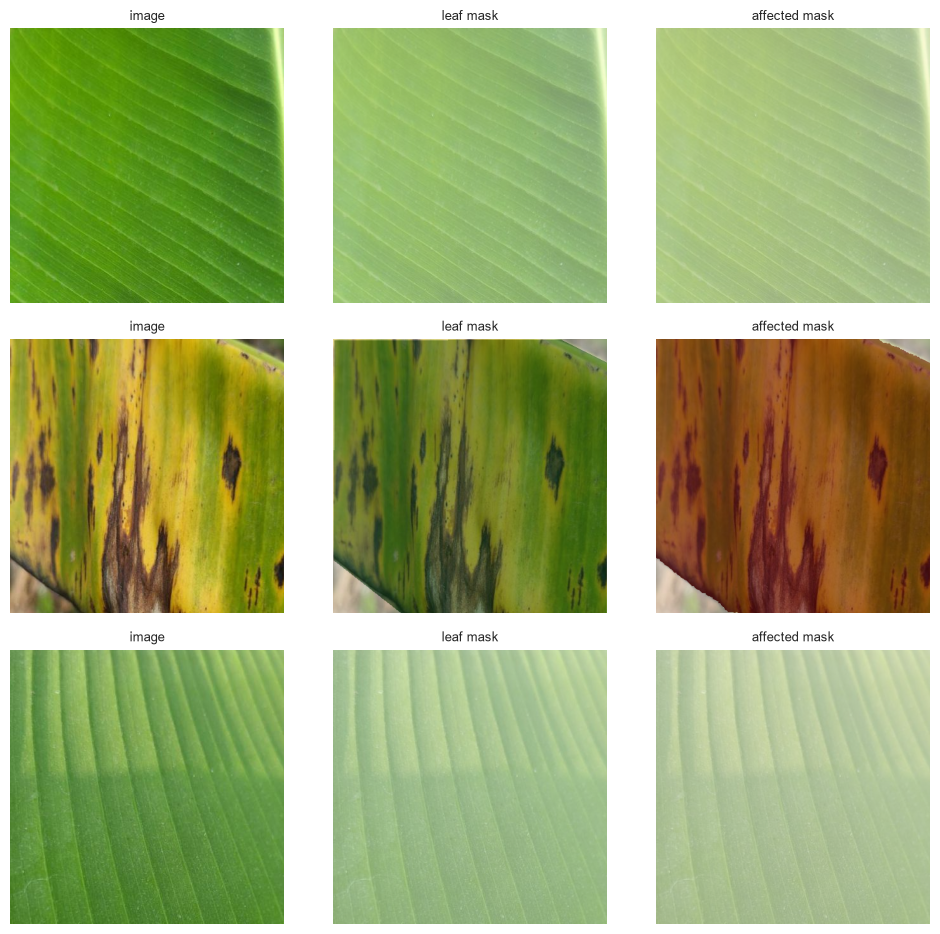

In [5]:

def visualize_sample(row, ax_row):
    img_path = RAW_DIR / row["split"] / "images" / row["file"]
    im = np.array(Image.open(img_path).convert("RGB"))
    h, w = im.shape[:2]
    masks = build_channel_masks(row["rows"], h, w)
    ax_row[0].imshow(im); ax_row[0].set_title("image", fontsize=9); ax_row[0].axis("off")
    ax_row[1].imshow(im); ax_row[1].imshow(masks["leaf"], alpha=0.4, cmap="Greens")
    ax_row[1].set_title("leaf mask", fontsize=9); ax_row[1].axis("off")
    ax_row[2].imshow(im); ax_row[2].imshow(masks["affected"], alpha=0.5, cmap="Reds")
    ax_row[2].set_title("affected mask", fontsize=9); ax_row[2].axis("off")

sample_rows = meta_df.sample(3, random_state=SEED)
fig, axes = plt.subplots(3, 3, figsize=(10, 9.5))
for ax_row, (_, row) in zip(axes, sample_rows.iterrows()):
    visualize_sample(row, ax_row)
plt.tight_layout()
save_fig(FIGURES_DIR / "01_sample_masks.png")
plt.show()


### 2.4 Pixel-level class balance (drives the BCE `pos_weight` in Section 5)

Leaf coverage:         mean=96.7%  median=100.0%
Affected (of image):   mean=8.77%  median=0.00%
Affected (of leaf):    mean=9.64%  median=0.00%
Fully healthy images (0 affected pixels): 86/161  (53%) — far better balanced than the reference repo's 2/50.


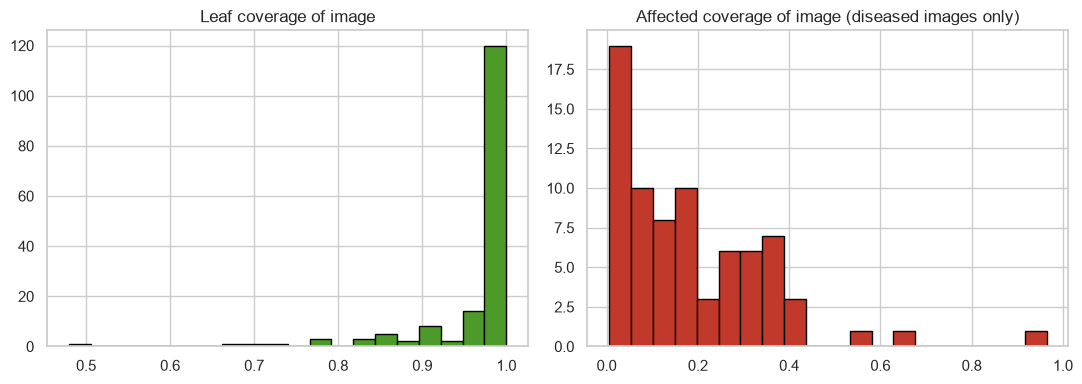

In [6]:

leaf_ratios, affected_ratios, affected_within_leaf = [], [], []
n_healthy = 0
sizes_cache = {}

for _, r in meta_df.iterrows():
    with Image.open(RAW_DIR / r["split"] / "images" / r["file"]) as im:
        w, h = im.size
    sizes_cache[r["file"]] = (h, w)
    masks = build_channel_masks(r["rows"], h, w)
    leaf_px = masks["leaf"].sum()
    aff_px = masks["affected"].sum()
    leaf_ratios.append(leaf_px / (h * w))
    affected_ratios.append(aff_px / (h * w))
    if leaf_px > 0:
        affected_within_leaf.append(aff_px / leaf_px)
    if aff_px == 0:
        n_healthy += 1

print(f"Leaf coverage:         mean={np.mean(leaf_ratios)*100:.1f}%  median={np.median(leaf_ratios)*100:.1f}%")
print(f"Affected (of image):   mean={np.mean(affected_ratios)*100:.2f}%  median={np.median(affected_ratios)*100:.2f}%")
print(f"Affected (of leaf):    mean={np.mean(affected_within_leaf)*100:.2f}%  median={np.median(affected_within_leaf)*100:.2f}%")
print(f"Fully healthy images (0 affected pixels): {n_healthy}/{len(meta_df)}  "
      f"({100*n_healthy/len(meta_df):.0f}%) — far better balanced than the reference repo's 2/50.")

GLOBAL_LEAF_MEAN = float(np.mean(leaf_ratios))
GLOBAL_AFFECTED_MEAN = float(np.mean(affected_ratios))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(leaf_ratios, bins=20, color="#4C9A2A", edgecolor="black")
axes[0].set_title("Leaf coverage of image")
axes[1].hist([x for x in affected_ratios if x > 0], bins=20, color="#C0392B", edgecolor="black")
axes[1].set_title("Affected coverage of image (diseased images only)")
plt.tight_layout()
save_fig(FIGURES_DIR / "02_pixel_coverage_distribution.png")
plt.show()


## 3. Data Preprocessing

### 3.1 Group-aware 70/15/15 split

In [7]:

meta_df["group"] = meta_df["stem"].apply(strip_roboflow_suffix)
print("Unique groups:", meta_df["group"].nunique(), " / images:", len(meta_df))

items = meta_df.index.tolist()
groups = meta_df["group"].tolist()
train_idx, val_idx, test_idx, best_seed = group_shuffle_split_3way(
    items, groups, train_size=0.70, val_size=0.15, seed=SEED
)
print(f"train={len(train_idx)}  val={len(val_idx)}  test={len(test_idx)}  (seed={best_seed})")

split_map = {}
for i in train_idx: split_map[i] = "train"
for i in val_idx:   split_map[i] = "val"
for i in test_idx:  split_map[i] = "test"
meta_df["my_split"] = meta_df.index.map(split_map)

print(meta_df.groupby("my_split").size())


Unique groups: 161  / images: 161


train=112  val=24  test=25  (seed=0)
my_split
test      25
train    112
val       24
dtype: int64


### 3.2 Cache decoded masks to disk

In [8]:

for idx, r in meta_df.iterrows():
    with Image.open(RAW_DIR / r["split"] / "images" / r["file"]) as im:
        w, h = im.size
    masks = build_channel_masks(r["rows"], h, w)
    stacked = np.stack([masks[c] for c in CHANNEL_NAMES], axis=-1)
    np.save(CACHE_DIR / f"{idx}.npy", stacked)

print(f"Cached {len(meta_df)} masks to {CACHE_DIR}")


Cached 161 masks to stage2_work\mask_cache


### 3.3 Augmentation pipeline (Albumentations)

In [9]:

import albumentations as A
from albumentations.pytorch import ToTensorV2

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE, interpolation=cv2.INTER_AREA),
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.3),
    A.Affine(translate_percent=0.05, scale=(0.85, 1.15), rotate=(-20, 20), p=0.6, border_mode=cv2.BORDER_CONSTANT),
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.8, 1.0), p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=15, p=0.4),
    A.GaussianBlur(blur_limit=(3, 5), p=0.15),
    A.GaussNoise(std_range=(0.02, 0.08), p=0.15),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE, interpolation=cv2.INTER_AREA),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])


### 3.4 PyTorch Dataset & DataLoader

In [10]:

class LeafSegDataset(Dataset):
    def __init__(self, indices, transform):
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        row_idx = self.indices[idx]
        r = meta_df.loc[row_idx]
        img = np.array(Image.open(RAW_DIR / r["split"] / "images" / r["file"]).convert("RGB"))
        mask = np.load(CACHE_DIR / f"{row_idx}.npy")
        augmented = self.transform(image=img, mask=mask)
        img_t = augmented["image"]
        mask_t = augmented["mask"].permute(2, 0, 1).float()
        return img_t, mask_t

train_ds = LeafSegDataset(train_idx, train_transform)
val_ds = LeafSegDataset(val_idx, val_transform)
test_ds = LeafSegDataset(test_idx, val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0)

print(f"train batches: {len(train_loader)}  val batches: {len(val_loader)}  test images: {len(test_ds)}")


train batches: 14  val batches: 3  test images: 25


### 3.5 Sanity check: augmented training batch

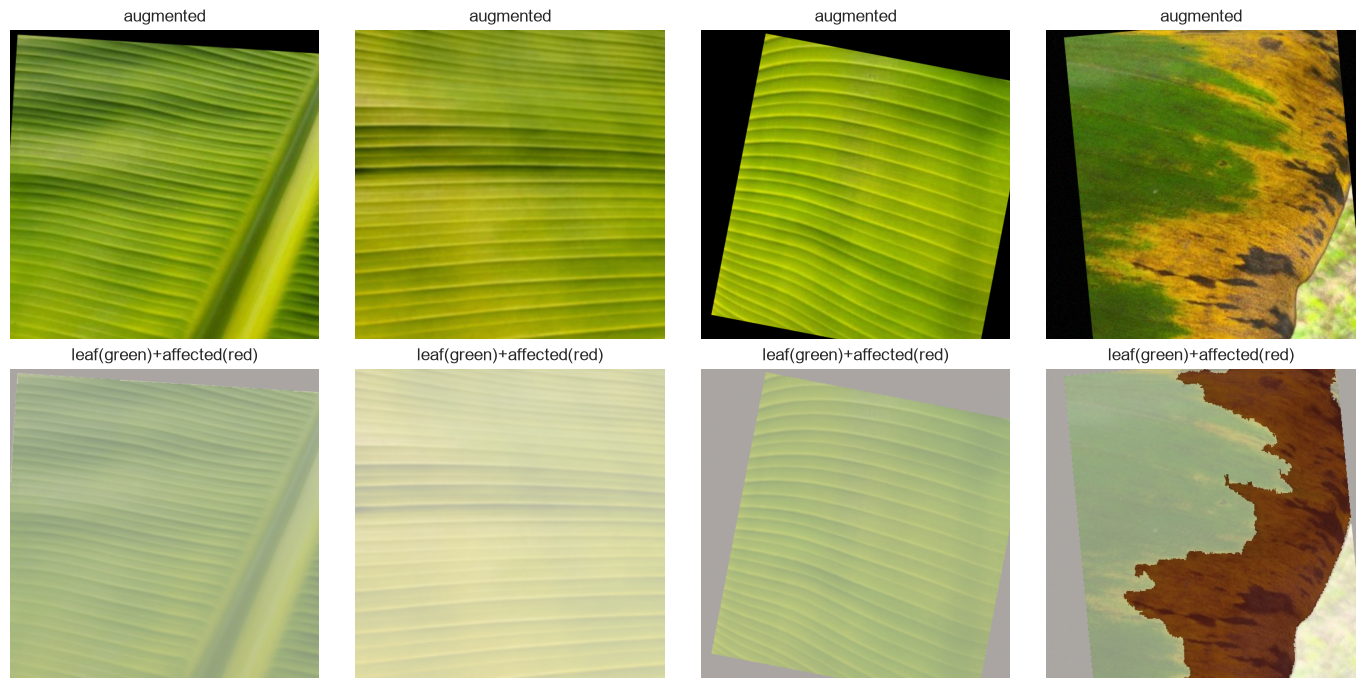

In [11]:

def denormalize(img_t):
    mean = np.array(IMAGENET_MEAN).reshape(3, 1, 1)
    std = np.array(IMAGENET_STD).reshape(3, 1, 1)
    img = img_t.numpy() * std + mean
    return np.clip(img.transpose(1, 2, 0), 0, 1)

imgs, masks = next(iter(train_loader))
n_show = min(4, imgs.shape[0])
fig, axes = plt.subplots(2, n_show, figsize=(3.5 * n_show, 7))
for i in range(n_show):
    axes[0, i].imshow(denormalize(imgs[i])); axes[0, i].set_title("augmented"); axes[0, i].axis("off")
    axes[1, i].imshow(denormalize(imgs[i]))
    axes[1, i].imshow(masks[i, 0], alpha=0.35, cmap="Greens")
    axes[1, i].imshow(masks[i, 1], alpha=0.5, cmap="Reds")
    axes[1, i].set_title("leaf(green)+affected(red)"); axes[1, i].axis("off")
plt.tight_layout()
save_fig(FIGURES_DIR / "03_augmented_batch_sanity_check.png")
plt.show()



## 4. Architecture

| Encoder | Params (full U-Net) | Notes |
|---|---|---|
| MobileNetV2 | ~6M | Lightest; some accuracy ceiling on fine lesion boundaries |
| **ResNet34** (chosen) | ~24M | Good accuracy/speed balance; matches the reference repo and the ADR 0012 production contract |
| EfficientNet-B0 | ~9M | Competitive accuracy at lower param count; fallback if memory-constrained |

**Output:** 2 raw-logit channels (`leaf`, `affected`) — multi-label (sigmoid), not mutually
exclusive classes, since `affected` is a strict subset of `leaf`.


In [12]:

import segmentation_models_pytorch as smp
from thop import profile

model = smp.Unet(
    encoder_name=ENCODER_NAME,
    encoder_weights="imagenet",
    in_channels=3,
    classes=len(CHANNEL_NAMES),
    activation=None,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,}")

dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
flops, _ = profile(model, inputs=(dummy,), verbose=False)
print(f"FLOPs (single {IMG_SIZE}x{IMG_SIZE} image): {flops/1e9:.2f} GFLOPs")


Total parameters: 24,436,514
FLOPs (single 512x512 image): 31.44 GFLOPs



## 5. Loss function

Dice (region overlap, robust to class imbalance) + weighted BCE (calibrated per-pixel
probabilities), `pos_weight` per channel computed from the actual measured pixel ratios
(Section 2.4), not a guessed constant — same approach as the reference repo and ADR 0012.


In [13]:

pos_weights = torch.tensor([
    compute_pos_weight(GLOBAL_LEAF_MEAN),
    compute_pos_weight(GLOBAL_AFFECTED_MEAN),
], dtype=torch.float32).to(DEVICE)
print("Per-channel BCE pos_weight (leaf, affected):", pos_weights.tolist())

criterion = ComboLoss(pos_weights)


Per-channel BCE pos_weight (leaf, affected): [0.03417697921395302, 10.40880298614502]



## 6. Deciding the optimizer

Short, identical-budget comparison (AdamW vs. SGD-momentum) on mean validation Dice, rather than
assuming AdamW by default.


In [14]:

def make_model():
    m = smp.Unet(encoder_name=ENCODER_NAME, encoder_weights="imagenet",
                 in_channels=3, classes=len(CHANNEL_NAMES), activation=None).to(DEVICE)
    return m

def quick_train_eval(optimizer_name, n_epochs):
    m = make_model()
    if optimizer_name == "AdamW":
        opt = torch.optim.AdamW(m.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    else:
        opt = torch.optim.SGD(m.parameters(), lr=LR * 10, momentum=0.9, weight_decay=WEIGHT_DECAY)

    for _ in range(n_epochs):
        m.train()
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            opt.zero_grad()
            logits = m(imgs)
            loss = criterion(logits, masks)
            loss.backward()
            opt.step()

    m.eval()
    total_dice = torch.zeros(len(CHANNEL_NAMES))
    n_batches = 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            logits = m(imgs)
            total_dice += dice_score(logits, masks).cpu()
            n_batches += 1
    return float((total_dice / n_batches).mean())

SWEEP_EPOCHS = 1 if SMOKE_TEST else 5
opt_sweep = {}
for name in ["AdamW", "SGD"]:
    score = quick_train_eval(name, SWEEP_EPOCHS)
    opt_sweep[name] = score
    print(f"{name}: mean val Dice after {SWEEP_EPOCHS} epochs = {score:.4f}")

best_optimizer_name = max(opt_sweep, key=opt_sweep.get)
print(f"\nSelected optimizer: {best_optimizer_name}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(opt_sweep.keys(), opt_sweep.values(), color=["#2A6F9A", "#C97B2A"])
ax.set_ylabel("mean val Dice"); ax.set_title(f"Optimizer sweep ({SWEEP_EPOCHS} epochs each)")
plt.tight_layout()
save_fig(FIGURES_DIR / "04_optimizer_sweep.png")
plt.show()


KeyboardInterrupt: 


## 7. Full training setup

- **Warmup (5 epochs, linear) → cosine anneal** via `SequentialLR`.
- **Mixed precision (AMP)** — active when `DEVICE=="cuda"`; a no-op context on this CPU laptop, so
  the same code is GPU-ready unchanged.
- **Gradient accumulation** (`GRAD_ACCUM_STEPS=2`) simulates batch size 12 without the memory cost.


In [ ]:

from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

model = make_model()
if best_optimizer_name == "AdamW":
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
else:
    optimizer = torch.optim.SGD(model.parameters(), lr=LR * 10, momentum=0.9, weight_decay=WEIGHT_DECAY)

warmup_scheduler = LinearLR(optimizer, start_factor=0.1, total_iters=WARMUP_EPOCHS)
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=max(EPOCHS - WARMUP_EPOCHS, 1))
scheduler = SequentialLR(optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[WARMUP_EPOCHS])

scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))


## 8. Training loop

In [ ]:

def run_epoch(loader, train_mode):
    model.train(train_mode)
    total_loss = 0.0
    total_dice = torch.zeros(len(CHANNEL_NAMES))
    n_batches = 0
    optimizer.zero_grad()
    for step, (imgs, masks) in enumerate(loader):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
            logits = model(imgs)
            loss = criterion(logits, masks)
            if train_mode:
                loss = loss / GRAD_ACCUM_STEPS
        if train_mode:
            scaler.scale(loss).backward()
            if (step + 1) % GRAD_ACCUM_STEPS == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
        total_loss += loss.item() * (GRAD_ACCUM_STEPS if train_mode else 1)
        total_dice += dice_score(logits.detach(), masks).cpu()
        n_batches += 1
    return total_loss / n_batches, (total_dice / n_batches).tolist()


In [ ]:

history = {"train_loss": [], "val_loss": [], "val_dice_leaf": [], "val_dice_affected": []}
best_val_dice = -1
epochs_no_improve = 0
best_ckpt_path = CHECKPOINT_DIR / "best_model.pt"

for epoch in range(EPOCHS):
    train_loss, _ = run_epoch(train_loader, train_mode=True)
    with torch.no_grad():
        val_loss, val_dice = run_epoch(val_loader, train_mode=False)
    scheduler.step()

    mean_val_dice = float(np.mean(val_dice))
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_dice_leaf"].append(val_dice[0])
    history["val_dice_affected"].append(val_dice[1])

    print(f"Epoch {epoch+1:3d}/{EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
          f"val_dice[leaf]={val_dice[0]:.3f} val_dice[affected]={val_dice[1]:.3f} | "
          f"lr={optimizer.param_groups[0]['lr']:.2e}")

    if mean_val_dice > best_val_dice:
        best_val_dice = mean_val_dice
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_ckpt_path)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1} (no val Dice improvement for {PATIENCE} epochs).")
            break

print(f"\nBest mean validation Dice: {best_val_dice:.4f}  (checkpoint: {best_ckpt_path})")


### 8.1 Training curves

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history["train_loss"], label="train loss")
axes[0].plot(history["val_loss"], label="val loss")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(history["val_dice_leaf"], label="val Dice (leaf)")
axes[1].plot(history["val_dice_affected"], label="val Dice (affected)")
axes[1].set_title("Validation Dice per channel"); axes[1].legend()
plt.tight_layout()
save_fig(FIGURES_DIR / "05_training_curves.png")
plt.show()


## 9. Evaluation

### 9.1 Test-set metrics (IoU, Dice, precision, recall) at default threshold 0.5

In [ ]:

model.load_state_dict(torch.load(best_ckpt_path))
model.eval()

channel_stats = {name: {"tp": 0, "fp": 0, "fn": 0, "tn": 0} for name in CHANNEL_NAMES}
with torch.no_grad():
    for imgs, masks in test_loader:
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        preds = (torch.sigmoid(logits) > 0.5).float().cpu()
        for c, name in enumerate(CHANNEL_NAMES):
            tp, fp, fn, tn = pixel_confusion(preds[:, c], masks[:, c])
            s = channel_stats[name]
            s["tp"] += tp; s["fp"] += fp; s["fn"] += fn; s["tn"] += tn

print(f"{'channel':<10} {'IoU':>7} {'Dice/F1':>9} {'Precision':>10} {'Recall':>8}")
for name in CHANNEL_NAMES:
    s = channel_stats[name]
    iou = s["tp"] / (s["tp"] + s["fp"] + s["fn"] + 1e-7)
    dice = 2 * s["tp"] / (2 * s["tp"] + s["fp"] + s["fn"] + 1e-7)
    precision = s["tp"] / (s["tp"] + s["fp"] + 1e-7)
    recall = s["tp"] / (s["tp"] + s["fn"] + 1e-7)
    print(f"{name:<10} {iou:7.3f} {dice:9.3f} {precision:10.3f} {recall:8.3f}")



### 9.2 Threshold sweep for the `affected` channel — **tuned on validation, not test**

ADR 0012 explicitly flags the reference notebook's threshold as tuned on its test split
(optimistic). We sweep on `val_loader` here and only touch the test set once, afterward, with the
threshold already fixed.


In [ ]:

def collect_probs_targets(loader):
    all_logits, all_targets = [], []
    with torch.no_grad():
        for imgs, masks in loader:
            logits = model(imgs.to(DEVICE)).cpu()
            all_logits.append(logits)
            all_targets.append(masks)
    return torch.cat(all_logits), torch.cat(all_targets)

val_logits, val_targets = collect_probs_targets(val_loader)
affected_idx = CHANNEL_NAMES.index("affected")
val_probs = torch.sigmoid(val_logits[:, affected_idx])
val_aff_targets = val_targets[:, affected_idx]

thresholds = np.arange(0.1, 0.95, 0.05)
ious = []
for t in thresholds:
    pred = (val_probs > t).float()
    tp = ((pred == 1) & (val_aff_targets == 1)).sum().item()
    fp = ((pred == 1) & (val_aff_targets == 0)).sum().item()
    fn = ((pred == 0) & (val_aff_targets == 1)).sum().item()
    ious.append(tp / (tp + fp + fn + 1e-7))

plt.figure(figsize=(7, 5))
plt.plot(thresholds, ious, marker="o")
plt.xlabel("Binarization threshold"); plt.ylabel("IoU (affected channel, VAL)")
plt.title("Threshold sweep — affected-area channel (tuned on validation)")
plt.grid(alpha=0.3)
save_fig(FIGURES_DIR / "06_threshold_sweep.png")
plt.show()

best_t = float(thresholds[int(np.argmax(ious))])
print(f"Best threshold (val-tuned): {best_t:.2f} (val IoU={max(ious):.3f})")
print(f"ADR 0012 production default for comparison: 0.5 (initial) / 0.85 (test-tuned, flagged optimistic)")


### 9.3 Final test-set metrics at the val-tuned threshold

In [ ]:

test_logits, test_targets = collect_probs_targets(test_loader)
test_probs = torch.sigmoid(test_logits[:, affected_idx])
test_aff_targets = test_targets[:, affected_idx]

pred_final = (test_probs > best_t).float().flatten().numpy().astype(int)
target_final = test_aff_targets.flatten().numpy().astype(int)

tp = int(((pred_final == 1) & (target_final == 1)).sum())
fp = int(((pred_final == 1) & (target_final == 0)).sum())
fn = int(((pred_final == 0) & (target_final == 1)).sum())
iou = tp / (tp + fp + fn + 1e-7)
dice = 2 * tp / (2 * tp + fp + fn + 1e-7)
print(f"TEST affected-channel @ threshold={best_t:.2f}:  IoU={iou:.3f}  Dice={dice:.3f}")

cm = np.array([
    [((pred_final == 0) & (target_final == 0)).sum(), ((pred_final == 1) & (target_final == 0)).sum()],
    [((pred_final == 0) & (target_final == 1)).sum(), ((pred_final == 1) & (target_final == 1)).sum()],
])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt=",", cmap="Blues",
            xticklabels=["pred: background", "pred: affected"],
            yticklabels=["true: background", "true: affected"], ax=ax)
ax.set_title("Pixel-level confusion matrix (affected, TEST)")
plt.tight_layout()
save_fig(FIGURES_DIR / "07_confusion_matrix.png")
plt.show()


## 10. Inference speed profiling

In [ ]:

sample_img, _ = test_ds[0]
sample_img = sample_img.unsqueeze(0).to(DEVICE)
for _ in range(5):
    with torch.no_grad():
        _ = model(sample_img)

n_runs = 20
t0 = time.perf_counter()
for _ in range(n_runs):
    with torch.no_grad():
        _ = model(sample_img)
elapsed = time.perf_counter() - t0
latency_ms = (elapsed / n_runs) * 1000
print(f"Device: {DEVICE}  |  Avg latency: {latency_ms:.1f} ms/image  ({1000/latency_ms:.1f} FPS)")


## 11. Edge-case / qualitative analysis — worst test-set predictions

In [ ]:

per_image_dice = []
with torch.no_grad():
    for i in range(len(test_ds)):
        img_t, mask_t = test_ds[i]
        logits = model(img_t.unsqueeze(0).to(DEVICE))
        pred = (torch.sigmoid(logits[0, affected_idx]) > best_t).float().cpu()
        target = mask_t[affected_idx]
        inter = (pred * target).sum().item()
        union = pred.sum().item() + target.sum().item()
        d = (2 * inter + 1e-7) / (union + 1e-7)
        per_image_dice.append((d, i))

per_image_dice.sort()
worst = per_image_dice[:4]
fig, axes = plt.subplots(len(worst), 3, figsize=(10, 3.2 * len(worst)))
if len(worst) == 1:
    axes = axes[None, :]
for row, (dice_val, idx) in zip(axes, worst):
    img_t, mask_t = test_ds[idx]
    with torch.no_grad():
        logits = model(img_t.unsqueeze(0).to(DEVICE))
        pred = (torch.sigmoid(logits[0, affected_idx]) > best_t).float().cpu()
    img_disp = denormalize(img_t)
    row[0].imshow(img_disp); row[0].set_title("image"); row[0].axis("off")
    row[1].imshow(img_disp); row[1].imshow(mask_t[affected_idx], alpha=0.5, cmap="Reds")
    row[1].set_title("ground truth"); row[1].axis("off")
    row[2].imshow(img_disp); row[2].imshow(pred, alpha=0.5, cmap="Reds")
    row[2].set_title(f"prediction (Dice={dice_val:.2f})"); row[2].axis("off")
plt.tight_layout()
save_fig(FIGURES_DIR / "08_worst_predictions.png")
plt.show()



## 12. Deriving the production label (ADR 0012 post-processing contract)

`no_leaf` if leaf < 3% of image · `affected` if damage ≥ 0.5% of leaf · else `healthy`.
Reproduced here so the notebook's own numbers can be sanity-checked against what the backend
would actually report for the same predictions.


In [ ]:

def derive_label(leaf_mask, affected_mask, leaf_frac_thresh=0.03, damage_frac_thresh=0.005):
    img_px = leaf_mask.numel()
    leaf_px = leaf_mask.sum().item()
    if leaf_px / img_px < leaf_frac_thresh:
        return "no_leaf"
    damage_frac = affected_mask.sum().item() / max(leaf_px, 1)
    return "affected" if damage_frac >= damage_frac_thresh else "healthy"

labels = []
with torch.no_grad():
    for i in range(len(test_ds)):
        img_t, mask_t = test_ds[i]
        logits = model(img_t.unsqueeze(0).to(DEVICE))[0].cpu()
        leaf_pred = torch.sigmoid(logits[0]) > 0.5
        affected_pred = torch.sigmoid(logits[1]) > best_t
        labels.append(derive_label(leaf_pred, affected_pred))

print("Predicted label distribution on test set:", Counter(labels))



## 13. Known limitations & next steps

- **Threshold tuned on 30 validation images** — a methodological improvement over the reference
  notebook, but still a small sample; revisit once more data exists.
- **`cordana` (1 image total) is folded into the generic `affected` channel** — too sparse to
  evaluate in isolation; Model 3 handles disease-type discrimination, and excludes it outright
  there for the same reason.
- **CPU-only training** — epoch budget sized for a laptop with no CUDA GPU.
- **Group-safe split found no leakage to fix** here (unlike Model 1's dataset), but is still
  applied for consistency and to make the three notebooks' methodology directly comparable.

## 14. Save model


In [ ]:

shutil.copy2(best_ckpt_path, OUTPUT_DIR / "leaf_segmentation_best.pt")
print(f"Saved: {(OUTPUT_DIR / 'leaf_segmentation_best.pt').resolve()}")
